# The Small Business Boom

In recent years, the digital landscape has seen a remarkable influx of small businesses, many of which owe their visibility, and in some cases, their rapid rise, to the power of social media. Platforms like TikTok, Instagram, and X (formerly Twitter) have given entrepreneurs unprecedented access to audiences that once required expensive marketing campaigns to reach. A single viral post can catapult a local startup into global recognition overnight.

But how sustainable is this success? Our team set out to explore a key question at the intersection of data science and digital marketing: does short-term virality translate into long-term business growth? By analyzing everything from big-picture business census information to analyzing engagement metrics of specific instances of viral small businesses over time, we aim to uncover whether social media fame is a fleeting spark or a foundation for lasting success in today’s small business ecosystem.

In [ ]:
import numpy as np
import pandas as pd

import seaborn
from matplotlib import pyplot

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize

from sklearn.cluster import KMeans
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#from wordcloud import WordCloud, STOPWORDS
import string
from matplotlib import pyplot as plt

import duckdb
import matplotlib.dates as mdates
import textwrap

Social economic conditions drive consumer behavior and the financial capacity of households. Small business success serves as an essential representation of social and economic status, because of their relationship with entry barriers and consumer demand. As context, we aimed to analyze the general trend in the evolution of small businesses and investigate its relationship with societal changes that may have shaped these patterns.

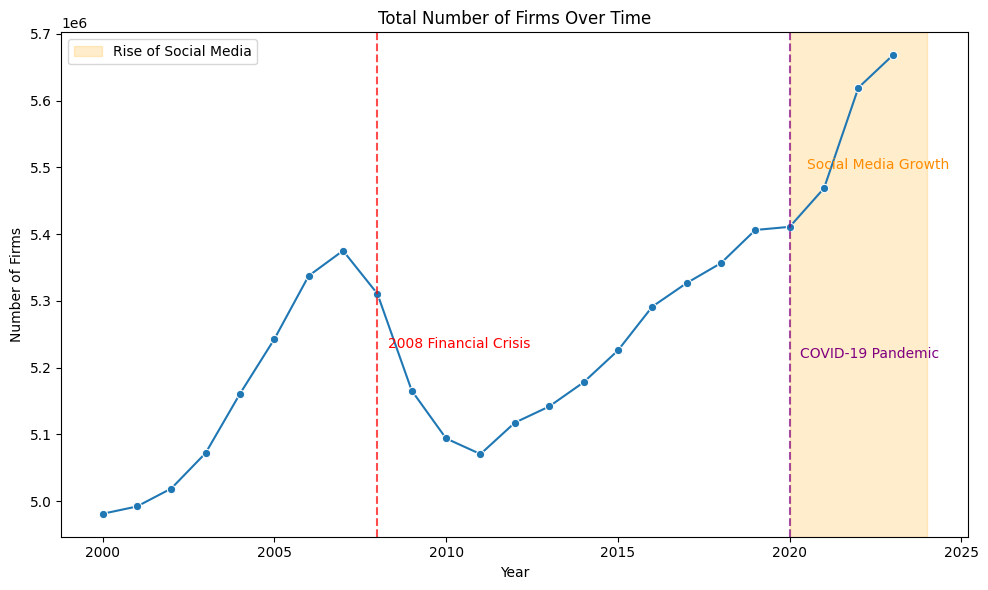

When visualizing the changes in total number of small businesses over time, we observed that the fluctuations closely correspond to major social and economic milestones. The total number of firms began to decline around 2007 and reached its lowest point around 2011, likely due to the Great Recession, which limited access to credit and reduced the financial capacity of entrepreneurs. After 2011, there was a noticeable acceleration in firm growth, with an especially sharp increase after 2020. This coincides with the widespread adoption of platforms such as Instagram and TikTok for marketing, suggesting that social media has lowered barriers to visibility and market entry for smaller firms.

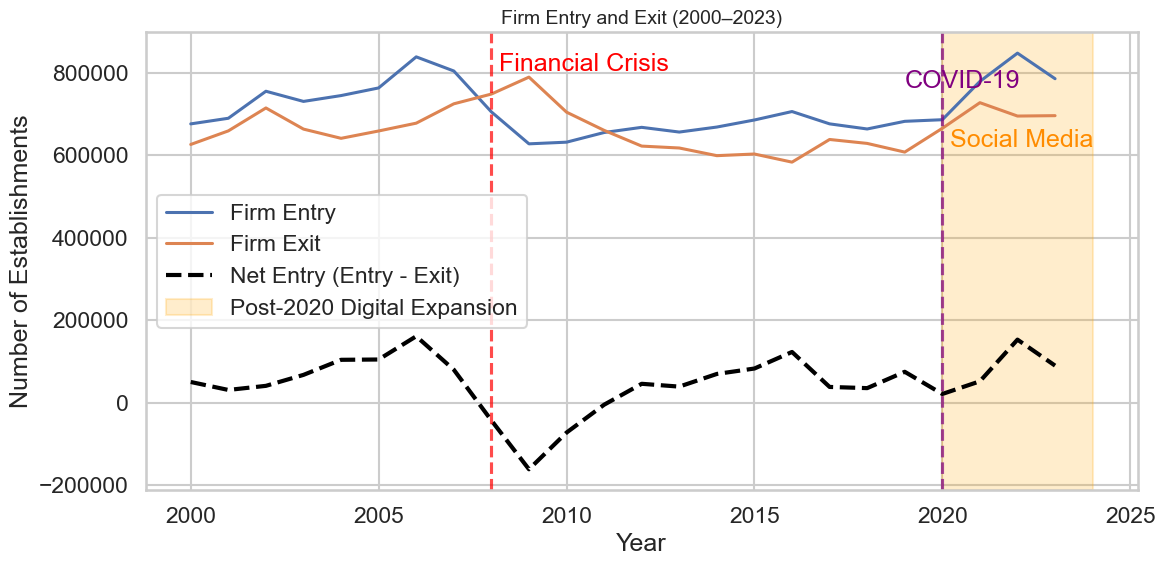

The entry and exit trends further reinforce this pattern. The sharp drop in net entry during 2006-2009 further reflects the financial crisis of that period. Firm exits spiked during COVID-19 pandemic in 2020, but entries rebounded strongly afterward, resulting in a positive net entry rate, possibly due to social media. 
Together, these contextual data allow us to identify a general pattern in small business activity and the factors influencing it. Particularly, the widespread adoption of social media appears to be the major driver of recent growth trends.

Although general trends provide insights into the relationship between small businesses and social media, we then investigate a more direct connection between social media activity and small business success and sustainability.

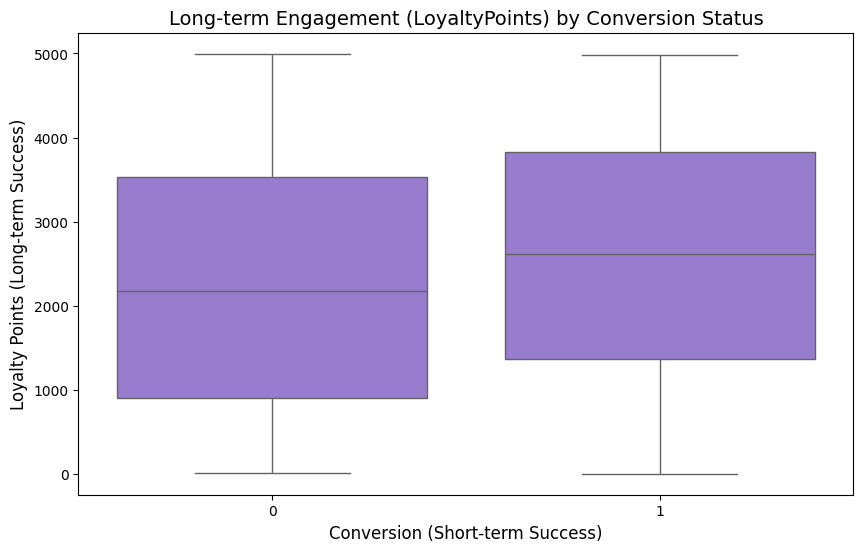

This dataset we analyzed offers a comprehensive view of customer interactions with digital marketing campaigns. The boxplot of loyalty points by conversion status shows that social media campaigns with successful conversions generally have higher loyalty points. This reveals that customers who respond positively to social media campaigns are more likely to make repeat purchases, indicating long-term effect and sustained success for small businesses.

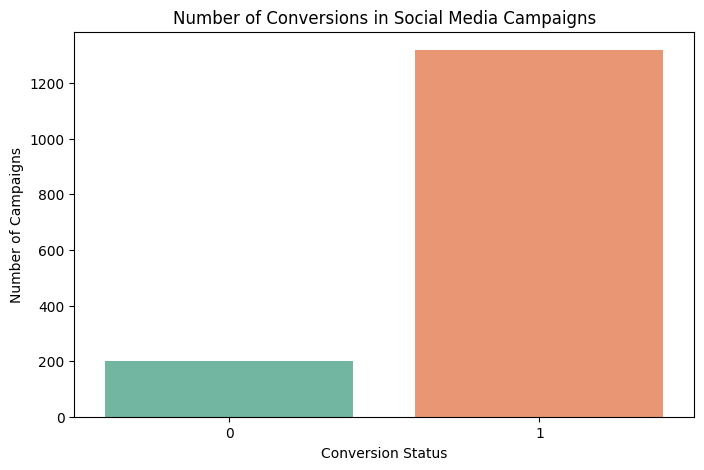

The bar chart illustrates that a much larger number of social media campaigns achieve successful conversions. This demonstrates the effectiveness of social media in driving campaign success, highlighting its value in marketing and advertisement efforts.

However, when examining conversion rate by marketing channel, we see that different channels display similar conversion rates. While we cannot conclude that social media dominates in terms of conversion rate compared to other channels, it still plays a significant role by generating a substantial number of success campaigns.

While virality can propel a business into the spotlight, lasting success often depends on more traditional indicators of stability and growth—like access to financing. One way to gauge whether viral visibility translates into tangible business progress is to look at lending activity. The U.S. Small Business Administration’s 7(a) loan program, a key source of funding for small enterprises, provides a useful lens for examining how small business confidence and creditworthiness have evolved in the social media era.

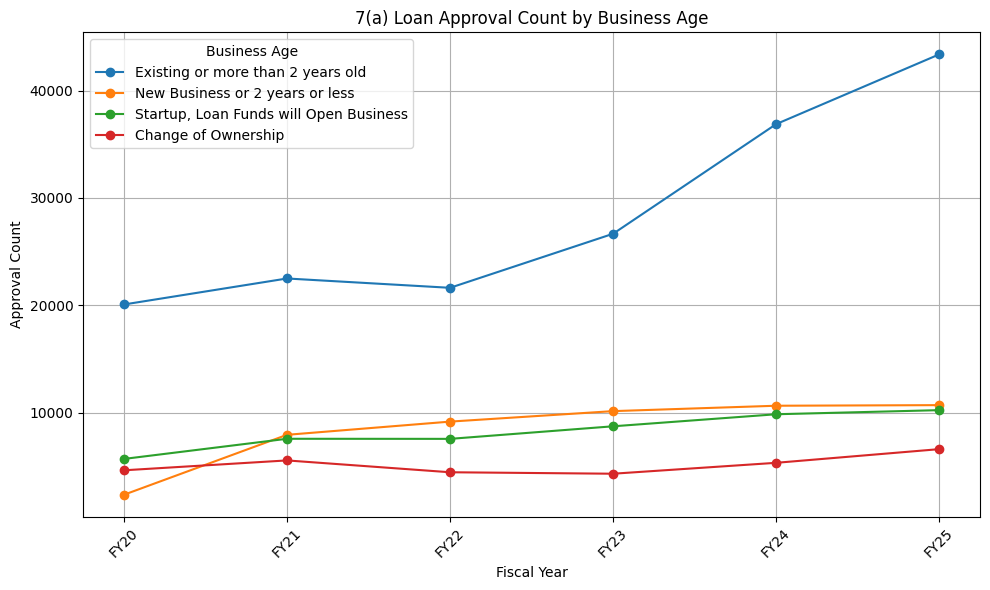

In [13]:
df = pd.read_csv("SBA-7(a)-and-504.csv")

loan_df = df.loc[(df.index == 0) | (~df.isna().any(axis=1))].copy()

for col in loan_df.columns[1:]:  
    loan_df.loc[:,col] = (
        loan_df[col]
        .astype(str)         
        .str.replace(r'[,$%]', '', regex=True) 
        .str.strip()         
    )
    loan_df.loc[:, col] = pd.to_numeric(loan_df[col], errors='coerce')

biz_age_rows = [
    "Business Age - Existing or more than 2 years old",
    "Business Age - New Business or 2 years or less",
    "Business Age - Startup, Loan Funds will Open Business",
    "Business Age - Change of Ownership"
]

count_7a_cols = [
    "FY20 7(a) Approval Count", 
    "FY21  7(a) Approval Count", 
    "FY22 7(a) Approval Count", 
    "FY23 7(a) Approval Count", 
    "FY24 7(a) Approval Count", 
    "FY25 7(a) Approval Count"
]

cols = ', '.join([f'"{c}"' for c in (["Portfolio Segment"] + count_7a_cols)])

query = f"""
SELECT {cols}
    FROM loan_df
    WHERE "Portfolio Segment" IN (SELECT UNNEST($biz_ages))
"""
count_7a_df = duckdb.execute(query, {'biz_ages': biz_age_rows}).df()

count_7a_df.set_index('Portfolio Segment', inplace=True)

df_plot = count_7a_df.T

# Clean up x-axis labels to only include year
df_plot.index = df_plot.index.str.extract(r'(FY\d{2})')[0]

# Clean up legend labels
df_plot.columns = df_plot.columns.str.replace(r'^Business Age - ', '', regex=True)

plt.figure(figsize=(10,6))
for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], marker='o', label=col)

plt.title("7(a) Loan Approval Count by Business Age")
plt.xlabel("Fiscal Year")
plt.ylabel("Approval Count")
plt.xticks(rotation=45)
plt.legend(title="Business Age")
plt.grid(True)
plt.tight_layout()
plt.show()

Established small businesses are on the rise. 7(a) loans are designed to support small businesses by providing financing for working capital, expansion, and equipment purchases (https://www.sba.gov/funding-programs/loans/7a-loans). Over the past five years, 7(a) loans for established small businesses (those operating for more than two years) have more than doubled, indicating stronger lending activity among mature firms. This trend may reflect growing lender confidence and small business optimism, as well as broader post-pandemic recovery and policy support that have made financing more accessible. Given the rise in social media marketing during this period, it remains unclear whether the accessibility and broad reach of these digital platforms have played a role in helping small businesses achieve this level of growth and perceived creditworthiness.

Yet, even as more established firms secure funding and expand operations, growth does not come without obstacles. Financing may fuel opportunity, but sustaining a competitive edge still hinges on market reach and customer engagement. To better understand the hurdles small businesses face in this new digital-first economy, we turn to survey data that highlights what entrepreneurs themselves identify as their most pressing challenges.

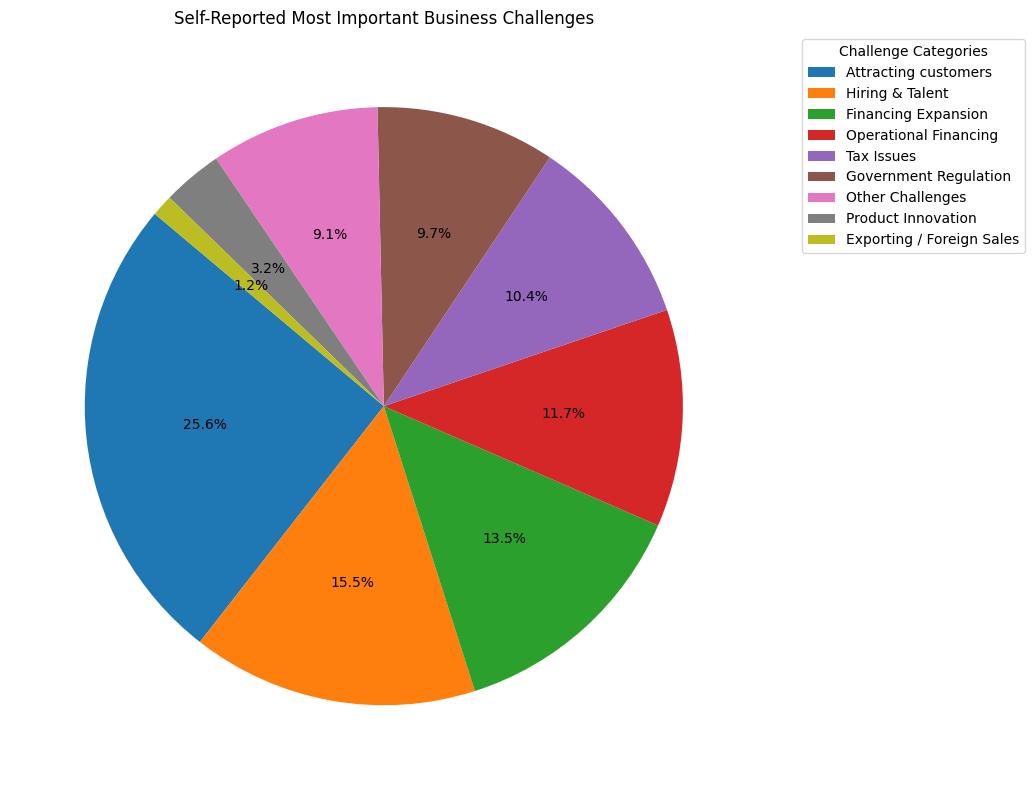

In [4]:
meta_df = pd.read_csv("aggregate_smb_leaders.csv")

# Questions of interest
questions = [
    "Is this business currently both operating and engaged in revenue generating activities?",
    "How long ago did this business begin operations?",
    "Does your business currently use the services of a bank or any other financial institution? By services, we mean services such as those used to save money, make or receive payments and wages, or to receive financial help.",
    "Within the past 12 months, did your business apply for any new lines of credit or loans?",
    "Did your business ever have an outstanding line of credit or loan within the past 3 years?",
    "In the next 12 months, does your business plan to make any large new investments (e.g., machinery and equipment, new or expanded facilities, or research and development projects)?",
    "Thinking about the past 12 months, what types of government support did this business receive?",
    "In which economic sector does this business operate?",
    "What are the most important challenges your business currently faces? (Please select up to two)"
]


questions_sql = ', '.join(f"'{q}'" for q in questions)

query = f"""
SELECT 
    REPLACE("value", 'Checked: ', '') AS value_label,
    "mean_w"
FROM meta_df
WHERE "logged_iso2" = 'US'
  AND "question_text" = 'What are the most important challenges your business currently faces? (Please select up to two)'
  AND "question_text" IN ({questions_sql})
  AND "value" LIKE 'Checked: %'
"""

plot_df = duckdb.execute(query).df()

# Sort descending by mean_w
plot_df = plot_df.sort_values('mean_w', ascending=False)

# Rename categories
rename_map = {
    "Retaining or recruiting skilled employees": "Hiring & Talent",
    "Securing financing for expansion": "Financing Expansion",
    "Securing financing for business as usual": "Operational Financing",
    "Tax laws and rules": "Tax Issues",
    "Government regulations (e.g., compliance, technical regulation, patents, reporting)": "Government Regulation",
    "Something not listed here": "Other Challenges",
    "Developing new products or innovation": "Product Innovation",
    "Selling to foreign markets": "Exporting / Foreign Sales"
}

plot_df['value_label'] = plot_df['value_label'].replace(rename_map)

# Create the figure
plt.figure(figsize=(10, 8))

# Draw pie chart (no labels on slices — cleaner with many categories)
patches, texts, autotexts = plt.pie(
    plot_df['mean_w'],
    autopct='%1.1f%%',
    startangle=140
)

# Add legend (index box)
plt.legend(
    patches,
    plot_df['value_label'],
    title="Challenge Categories",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("Self-Reported Most Important Business Challenges")
plt.tight_layout()
plt.show()


For these growing small businesses, attracing customers is the main challenge. Meta has collaborated with the World Bank and the Organisation for Economic Co-operation and Development (OECD) to conduct surveys of small businesses. According to these surveys, attracting customers is the top challenge reported by American small businesses. This finding shows the need for effective marketing strategies.

In [ ]:
biz_df = pd.read_csv("small_business_searches.csv", skiprows=1)
biz_df['Month'] = pd.to_datetime(biz_df['Month'])
sm_df = pd.read_csv("social_media_searches.csv", skiprows=1)
sm_df['Month'] = pd.to_datetime(sm_df['Month'])

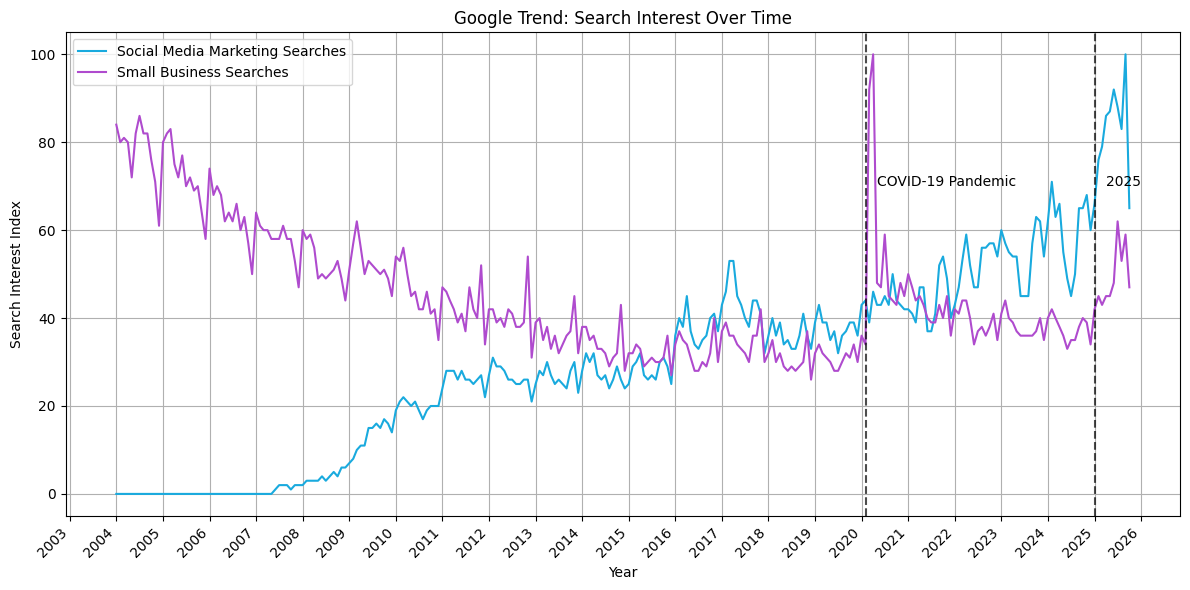

In [ ]:
# Plot both relationships on the same graph
plt.figure(figsize=(12,6))
plt.plot(sm_df['Month'], sm_df['social media marketing: (United States)'], color='#19AADE', label='Social Media Marketing Searches')
plt.plot(biz_df['Month'], biz_df['small business: (United States)'], color='#AF4BCE', label='Small Business Searches')

#2025
plt.axvline(x=pd.to_datetime('2025-01'), color='black', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2025-04'), sm_df['social media marketing: (United States)'].max()*0.7, '2025', color='black')

#covid
plt.axvline(x=pd.to_datetime('2020-02'), color='black', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2020-05'), sm_df['social media marketing: (United States)'].max()*0.7, 'COVID-19 Pandemic', color='black')

# 1. Get the current axes
ax = plt.gca()

# 2. Set the Major Locator to show a tick mark every YEAR
ax.xaxis.set_major_locator(mdates.YearLocator())

# 3. Set the Major Formatter to display the year (e.g., '2022')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 4. Optional: Rotate the labels for better readability
plt.xticks(rotation=45, ha='right')

# --- Final Touches ---
plt.xlabel("Year")
plt.ylabel("Search Interest Index")
plt.title("Google Trend: Search Interest Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Could the rising interest in social media marketing be the solution to this challenge? The graph above shows relative Google searches for Social Media Marketing (blue) and Small Business (purple). Google search interest measures  the relative popularity of a search query over time, displayed on a scale of 0 to 100 where 100 represents the period of highest popularity for that specific query within the selected time frame. While interest in small businesses have generally declined since 2003, there was significantly more interest during the pandemic and right now in 2025. Given the uptick in interest in both small businesses and social media marketing in 2025, it is especially relevant to understand how social media virality affects small business's long term success. 

To move beyond broad trends and search interest data, it’s helpful to examine how virality actually plays out in real-world business outcomes. Social media platforms, particularly TikTok, have become powerful engines for rapid visibility, where a single video can transform a local brand into a household name overnight. However, the real test lies in what happens after the initial surge of attention fades. By looking at specific examples of small businesses that went viral on TikTok and tracing their trajectories since that moment, we can better understand whether social media fame translates into sustained growth, repeat customers, and long-term business viability.

**Examples from TikTok API research to be inserted here**

Across our analysis, a consistent pattern emerges: while social media virality can spark impressive short-term gains in visibility, sales, and engagement, these effects often taper unless businesses are prepared to convert attention into sustainable operations. The data on 7(a) loan approvals and business challenges suggests that lasting growth is typically driven by fundamentals such as financial planning, customer retention, and long-term marketing strategy, not just by viral moments. Simultaneously, the growing interest in social media marketing indicates that small business owners increasingly recognize the potential of digital platforms as tools for visibility and brand building. The examples of viral TikTok businesses show that success stories do exist, especially for those who leverage viral momentum to build strong customer communities and diversify their sales channels. However, for every viral success that becomes a lasting brand, there exists many other businesses that struggle to maintain relevance once the initial surge of attention fades.

Social media virality should be not seen as a guaranteed path to success but rather as an opportunity; it can be a powerful accelerator when combined with solid business fundamentals. As small businesses continue to navigate a rapidly evolving digital landscape, the most resilient and lasting businesses will be those that treat virality as a spark for sustainable growth rather than an end in itself.

Enchanted Scrunch by Dasha

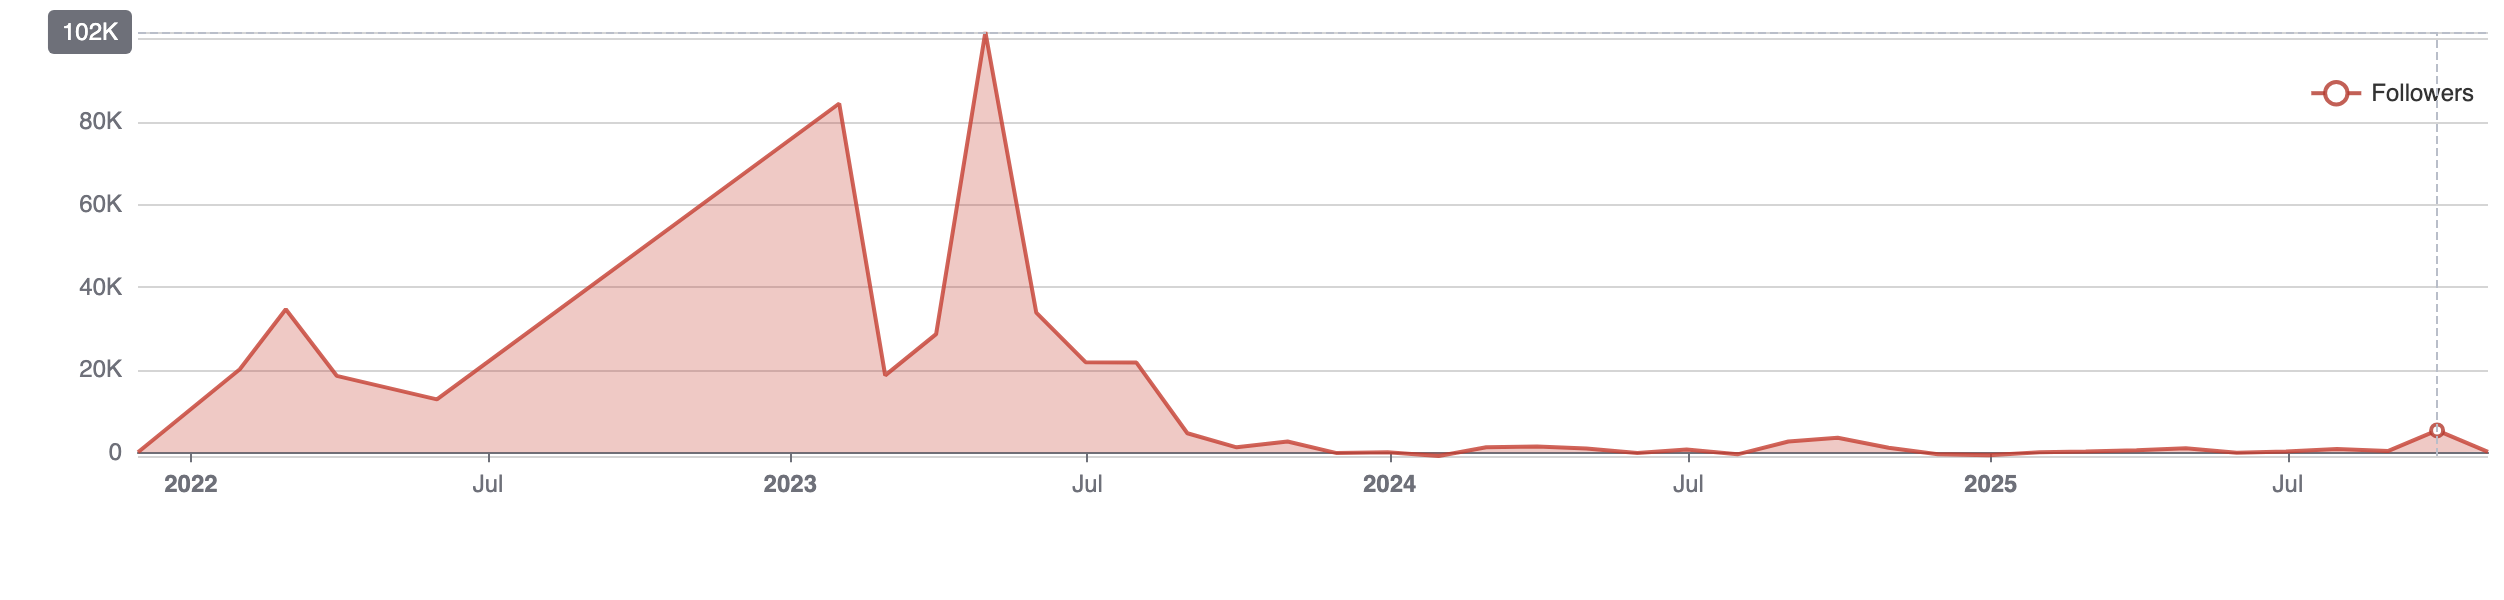

Enchanted Scrunch by Dasha is a small handmade scrunchie shop that unexpectedly went viral on Tiktok. Her videos have a cozy, real vibe: sewing at the desk, packing orders late at night, and talking about balancing school and her small business. Her videos gathered a huge wave of attention. As shown in the graph, there are some ups and downs at the start, then a sudden jump in April when her follower growth hit its highest point.
But just as quickly as it took off, it dropped. A few months after the peak, the number of new followers basically fell to around zero, and to this day the account isn't really gaining any new followers at all.
This pattern perfectly matches how most small business experience virality in real time. Small businesses like Enchanted Scrunch by Dasha show how social media can give them a place for huge exposure, but not stable success. The gap between going viral and actually surviving long-term is what we want to understand and try to improve.

BOPOMOFO CAFE illustrates how social media alone can’t fully overcome the challenge of attracting customers when a product is highly seasonal. The Asian American café, founded by Phil Wang of Wong Fu Productions and Eric Wang, has six California locations and a strong online presence due to Phil’s 3-million-subscriber YouTube following from Wong Fu Productions.

In October, the café used Instagram to openly acknowledge the food-and-beverage industry’s winter slow season and encouraged followers to support small businesses. They noted that social media can create the impression they are larger or more successful than they are, and chose to be transparent about the difficulty of maintaining traffic in colder months.

![BOPOMOFO CAFE Instagram Post](bopomofo_insta_post.png)

Their follower data reflects this seasonality: increases typically occur in the summer, while declines are common in winter, suggesting that social media visibility can’t fully counteract seasonal demand patterns. However, this year the café has maintained steady follower growth even into November, indicating they may be improving at using social media to sustain engagement during slower periods.

![BOPOMOFO CAFE Monthly Gained Followers](bopomofo.png)